# Plan-and-Execute

이번 강의에서는 복잡한 멀티스텝 태스크를 처리하는 Plan-and-Execute 패턴을 배운다. 전체 계획을 먼저 세우고, 단계별로 실행하며, 중간 결과에 따라 계획을 수정(Re-planning)하는 구조다.

In [13]:
from dotenv import load_dotenv

load_dotenv()

True

## Plan-and-Execute란

ReAct Agent는 **한 번에 한 단계씩** 생각하고 행동한다. 간단한 질문에는 잘 동작하지만, 복잡한 태스크에서는 한계가 있다.

| | ReAct | Plan-and-Execute |
|---|---|---|
| 전략 | 한 단계씩 결정 | 전체 계획을 먼저 수립 |
| 장점 | 단순, 빠름 | 복잡한 태스크에 강함 |
| 단점 | 큰 그림을 놓칠 수 있음 | 계획 수립에 비용 발생 |
| 적합한 경우 | 단일 검색, 간단한 질의 | 멀티스텝 조사, 보고서 작성 |

예를 들어 "경쟁사 3곳의 AI 서비스 가격을 조사해서 비교표를 만들고 보고서를 작성해줘"라는 요청을 생각해보자.

- **ReAct**: 첫 번째 경쟁사를 검색 -> 결과를 보고 다음을 결정 -> ... (방향을 잃기 쉬움)
- **Plan-and-Execute**: 먼저 "1) A사 가격 조사 2) B사 가격 조사 3) C사 가격 조사 4) 비교표 작성 5) 보고서 작성"이라는 계획을 세우고, 하나씩 실행

핵심 흐름은 다음과 같다.

```
입력 → Planner(계획 수립) → Executor(단계 실행) → Replanner(계획 수정) → ... → 최종 응답
```

## State 설계

Plan-and-Execute의 State는 이전보다 복잡하다. 계획, 실행 결과, 최종 응답을 모두 추적해야 한다.

| 필드 | 타입 | 역할 |
|------|------|------|
| `input` | `str` | 사용자의 원래 요청 |
| `plan` | `list[str]` | 현재 계획 (단계 목록) |
| `past_steps` | `list[tuple]` | 완료된 단계와 결과 (누적) |
| `response` | `str` | 최종 응답 |

`past_steps`에는 `operator.add` reducer를 사용해서 실행 결과가 계속 누적되도록 한다. `plan`은 Replanner가 통째로 교체할 수 있어야 하므로 reducer 없이 덮어쓰기로 둔다.

State 설계 판단 기준:
- **누적이 필요한 데이터** (실행 이력) -> reducer 사용
- **최신 값만 필요한 데이터** (현재 계획, 최종 응답) -> reducer 없이 덮어쓰기
- **불필요한 데이터는 넣지 않는다** -> State가 커지면 LLM에 전달할 컨텍스트도 커져서 비용이 증가한다

In [14]:
import operator
from typing import Annotated, TypedDict


class PlanExecuteState(TypedDict):
    input: str
    plan: list[str]
    past_steps: Annotated[list[tuple], operator.add]
    response: str

## Tool 정의

Executor가 사용할 Tool을 먼저 정의한다. 여기서는 웹 검색 도구를 사용한다.

In [15]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=3)

tools = [search]

## 노드 구현

3개의 핵심 노드를 만든다.

1. **Planner** - 사용자 입력을 받아 실행 계획을 생성
2. **Executor** - 계획의 현재 단계를 실행
3. **Replanner** - 중간 결과를 보고 계획을 수정하거나 최종 응답을 생성

### Planner

Structured Output으로 계획을 리스트 형태로 받는다.

프롬프트에서 최대 단계 수를 제한하는 것이 중요하다. 제한이 없으면 LLM이 지나치게 세분화된 계획을 생성할 수 있고, 단계가 많아질수록 실행 시간과 비용이 늘어난다. `recursion_limit`은 그래프 레벨의 안전장치이고, 프롬프트의 단계 수 제한은 계획 품질 자체를 높이는 역할이다.

In [16]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate


class Plan(BaseModel):
    """실행 계획"""
    steps: list[str] = Field(description="수행해야 할 단계들의 목록 (순서대로)")


planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 주어진 목표를 달성하기 위한 단계별 계획을 세우는 전문가입니다.
각 단계는 구체적이고 실행 가능해야 합니다.
불필요한 단계는 포함하지 마세요. 최종 단계의 결과가 곧 최종 응답이 됩니다.
계획은 최대 5단계 이내로 작성하세요.""",
    ),
    ("human", "{input}"),
])

planner_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
planner = planner_prompt | planner_llm.with_structured_output(Plan)

In [17]:
# Planner 단독 테스트
result = planner.invoke({"input": "경쟁사 AI 서비스 가격을 조사해서 비교 보고서를 만들어줘"})
print("생성된 계획:")
for i, step in enumerate(result.steps, 1):
    print(f"  {i}. {step}")

생성된 계획:
  1. 경쟁사 목록 작성: 주요 경쟁사 AI 서비스 제공업체를 선정하여 목록을 작성한다.
  2. 가격 정보 수집: 각 경쟁사의 웹사이트, 보도자료, 또는 가격 책정 페이지에서 AI 서비스의 가격 정보를 수집한다.
  3. 가격 비교 표 작성: 수집한 가격 정보를 바탕으로 경쟁사별 가격 비교 표를 작성한다.
  4. 보고서 작성: 가격 비교 표를 포함하여 각 경쟁사의 서비스 특징 및 가격 전략에 대한 분석을 포함한 보고서를 작성한다.
  5. 보고서 검토 및 제출: 작성한 보고서를 검토하고 필요한 수정 후 최종 보고서를 제출한다.


### Executor

현재 단계를 실행하는 Agent다. Tool을 사용할 수 있어야 하므로 ReAct 스타일의 Agent를 사용한다.

In [18]:
from langchain.agents import create_agent

executor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

agent_executor = create_agent(
    model=executor_llm,
    tools=tools,
)

### Replanner

지금까지의 실행 결과를 보고 두 가지 중 하나를 결정한다.

- 아직 할 일이 남았으면 -> 남은 계획을 수정해서 반환
- 충분하면 -> 최종 응답을 생성

여기서 `Union[Response, Plan]`을 사용한다. Structured Output에서 Union 타입을 쓰면, LLM이 **두 스키마 중 하나를 선택**해서 응답한다. 각 모델의 `description`이 판단 기준이 된다. LLM은 "최종 응답을 할 수 있으면 Response, 아직 단계가 남았으면 Plan"이라는 설명을 보고 어떤 스키마로 응답할지 결정한다.

In [19]:
from typing import Union


class Response(BaseModel):
    """사용자에게 전달할 최종 응답"""
    response: str = Field(description="최종 응답")


class Act(BaseModel):
    """수행할 행동. Response 또는 Plan 중 하나를 반환한다."""
    action: Union[Response, Plan] = Field(
        description="수행할 행동. 최종 응답을 할 수 있으면 Response, 아직 단계가 남았으면 Plan을 반환."
    )


replanner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 계획의 진행 상황을 평가하고 다음 행동을 결정하는 전문가입니다.

주어진 목표, 원래 계획, 그리고 지금까지 완료된 단계들을 보고:
1. 충분한 정보가 모였으면 최종 응답(Response)을 작성하세요.
2. 아직 부족하면 남은 단계를 수정/보완한 새 계획(Plan)을 반환하세요.

중요한 규칙:
- 이미 완료된 단계를 절대 다시 포함하지 마세요.
- 완료된 단계의 결과가 불완전하더라도 있는 정보를 활용하세요. 같은 주제를 반복 조사하지 마세요.
- 원래 계획의 모든 단계가 완료되었으면 반드시 Response를 반환하세요.""",
    ),
    (
        "human",
        """목표: {input}

원래 계획:
{plan}

완료된 단계:
{past_steps}

위 정보를 바탕으로 다음 행동을 결정하세요.""",
    ),
])

replanner_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
replanner = replanner_prompt | replanner_llm.with_structured_output(Act)

### 노드 함수 정의

위에서 만든 Chain/Agent를 State와 연결하는 노드 함수를 작성한다.

`execute_step`에서 항상 `state["plan"][0]`으로 첫 번째 단계를 실행한다. Replanner가 매번 **완료된 단계를 제거한 새 계획**을 반환하기 때문에, `plan[0]`은 항상 "다음에 실행할 단계"가 된다.

```
초기 계획: [A, B, C]  → execute A → replan → [B, C]  → execute B → replan → [C] → execute C → ...
```

In [20]:
from langchain_core.messages import HumanMessage


def plan_step(state: PlanExecuteState):
    """계획 수립 노드"""
    result = planner.invoke({"input": state["input"]})
    return {"plan": result.steps}


def execute_step(state: PlanExecuteState):
    """현재 단계 실행 노드"""
    # 계획의 첫 번째 단계를 실행
    current_step = state["plan"][0]

    # 이전 결과를 컨텍스트로 포함
    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\n지금까지의 결과:\n"
        for step, result in state["past_steps"]:
            past_context += f"- {step}: {result}\n"

    task = f"다음 작업을 수행하세요: {current_step}{past_context}"

    # ReAct Agent로 실행
    agent_response = agent_executor.invoke(
        {"messages": [HumanMessage(content=task)]}
    )
    result = agent_response["messages"][-1].content

    return {"past_steps": [(current_step, result)]}


def replan_step(state: PlanExecuteState):
    """계획 수정 노드"""
    result = replanner.invoke({
        "input": state["input"],
        "plan": "\n".join(f"{i+1}. {s}" for i, s in enumerate(state["plan"])),
        "past_steps": "\n".join(
            f"- {step}: {result}" for step, result in state["past_steps"]
        ),
    })

    if isinstance(result.action, Response):
        return {"response": result.action.response}
    else:
        return {"plan": result.action.steps}

## 그래프 구성

전체 그래프의 흐름은 다음과 같다.

```
START → planner → executor → replanner → executor → replanner → ... → END
```

Replanner에서 최종 응답이 생성되면 END로 가고, 아직 계획이 남아있으면 다시 Executor로 돌아간다.

In [21]:
from langgraph.graph import StateGraph, START, END


def should_continue(state: PlanExecuteState):
    """replanner 이후 분기: 응답이 있으면 종료, 없으면 계속 실행"""
    if state.get("response"):
        return "end"
    return "continue"


graph_builder = StateGraph(PlanExecuteState)

# 노드 추가
graph_builder.add_node("planner", plan_step)
graph_builder.add_node("executor", execute_step)
graph_builder.add_node("replanner", replan_step)

# 엣지 연결
graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_edge("executor", "replanner")
graph_builder.add_conditional_edges(
    "replanner",
    should_continue,
    {
        "continue": "executor",
        "end": END,
    },
)

graph = graph_builder.compile()

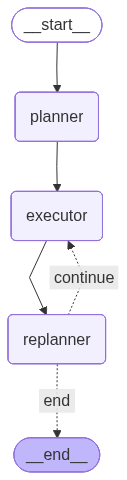

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 실행

멀티스텝이 필요한 질문으로 테스트한다.

In [23]:
config = {"recursion_limit": 20}

inputs = {"input": "경쟁사 AI 서비스 가격을 조사해서 비교 보고서를 만들어줘. OpenAI, Google, Anthropic 3곳을 대상으로 해줘."}

for event in graph.stream(inputs, config=config):
    for node_name, value in event.items():
        if node_name == "__end__":
            continue
        print(f"\n{'='*60}")
        print(f"[{node_name}]")
        print(f"{'='*60}")

        if node_name == "planner":
            print("계획:")
            for i, step in enumerate(value["plan"], 1):
                print(f"  {i}. {step}")

        elif node_name == "executor":
            step, result = value["past_steps"][-1]
            print(f"실행: {step}")
            print(f"결과: {result[:300]}...")

        elif node_name == "replanner":
            if value.get("response"):
                print("최종 응답:")
                print(value["response"])
            elif value.get("plan"):
                print("수정된 계획:")
                for i, step in enumerate(value["plan"], 1):
                    print(f"  {i}. {step}")


[planner]
계획:
  1. OpenAI의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
  2. Google의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
  3. Anthropic의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
  4. 각 서비스의 가격 정보를 정리하여 비교할 수 있는 표를 만든다.
  5. 비교 결과를 바탕으로 보고서를 작성한다.

[executor]
실행: OpenAI의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
결과: OpenAI의 AI 서비스 가격 정보는 다음 링크에서 확인할 수 있습니다:

- [OpenAI API 가격](https://openai.com/api/pricing/)

주요 가격 정보는 다음과 같습니다:

1. **GPT-5.4**
   - 입력: $2.50 / 1M 토큰
   - 출력: $15.00 / 1M 토큰

2. **GPT-5.4 mini**
   - 입력: $0.75 / 1M 토큰
   - 출력: $4.50 / 1M 토큰

3. **GPT-5.4 nano**
   - 입력: $0.20 / 1M 토큰
   - 출력: $1...

[replanner]
수정된 계획:
  1. Google의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
  2. Anthropic의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
  3. 각 서비스의 가격 정보를 정리하여 비교할 수 있는 표를 만든다.
  4. 비교 결과를 바탕으로 보고서를 작성한다.

[executor]
실행: Google의 AI 서비스 가격 정보를 공식 웹사이트에서 확인한다.
결과: Google의 AI 서비스 가격 정보는 다음 링크에서 확인할 수 있습니다:

1. **[Document AI Pricing](https://cloud.google.com/document-ai/pricing)**:
   - 기본 요금 예시:
     - 1년 동안 프로세서 버전 1개 배포 시 비용: $438
     - 문서 분류기

## Re-planning

Re-planning이 어떻게 동작하는지 좀 더 자세히 살펴보자.

Replanner는 매 단계 실행 후 호출되며, 다음 중 하나를 결정한다.

| 상황 | Replanner의 판단 | 결과 |
|------|------------------|------|
| 검색 결과가 충분함 | 남은 계획을 줄이거나 최종 응답 생성 | 효율적 |
| 검색 결과가 부족함 | 추가 검색 단계를 계획에 삽입 | 품질 향상 |
| 예상과 다른 결과 | 계획 자체를 수정 | 유연한 대응 |
| 모든 단계 완료 | 최종 응답 생성 | 종료 |

이것이 Plan-and-Execute의 핵심 강점이다. 단순히 계획을 세우고 실행하는 것이 아니라, **중간 결과에 따라 계획을 수정**할 수 있다.

Re-planning 시 주의할 점:
- `past_steps`에 이전 결과가 모두 누적되어 있으므로, Replanner가 맥락을 파악할 수 있다
- 무한 루프를 방지하기 위해 `recursion_limit`을 설정한다
- `past_steps`가 너무 길어지면 컨텍스트 윈도우를 초과할 수 있으므로, 결과를 요약하는 전략도 고려해야 한다

### 단계 실패 시 동작

Executor는 외부 API(검색, 데이터베이스 등)를 호출하기 때문에 다른 노드보다 실패 확률이 높다. 중간 단계가 실패하면 어떻게 될까?

Executor가 에러 없이 실패 결과를 반환하면, 그 결과가 `past_steps`에 저장된다. Replanner는 이를 보고 대응할 수 있다.

- 같은 단계를 다른 방식으로 재시도
- 해당 단계를 건너뛰고 다른 경로로 진행
- 이미 충분한 정보가 있으면 최종 응답 생성

하지만 Executor 내부에서 **예외가 발생**하면 노드 자체가 크래시하고 그래프 실행이 중단된다. 이를 방지하려면 try/except로 에러를 잡아 결과 문자열로 변환하면 된다. 그러면 Replanner가 실패를 인식하고 계획을 수정할 수 있다.

In [ ]:
def execute_step_safe(state: PlanExecuteState):
    """execute_step을 대체하는 노드. 에러를 잡아서 결과로 저장한다."""
    current_step = state["plan"][0]
    task = f"다음 작업을 수행하세요: {current_step}"

    try:
        agent_response = agent_executor.invoke(
            {"messages": [HumanMessage(content=task)]}
        )
        result = agent_response["messages"][-1].content
    except Exception as e:
        # 에러를 결과로 저장하면 Replanner가 대응할 수 있다
        result = f"실패: {e}"

    return {"past_steps": [(current_step, result)]}

# 그래프에서 executor 노드를 이 함수로 교체
# graph_builder.add_node("executor", execute_step_safe)

## 컨텍스트 관리

멀티스텝 Agent에서는 Tool 호출 결과 + 검색 결과 + 대화 히스토리가 동시에 쌓이면서 context window 압박이 생긴다.

### 관리 전략

| 전략 | 방법 | 적용 시점 |
|------|------|----------|
| **프롬프트 제한** | Executor에게 핵심만 정리하라고 지시 | 항상 (가장 효율적) |
| **Truncation** | 최대 길이를 정해 자르기 | 항상 (안전장치) |
| **결과 요약** | Tool 결과를 LLM으로 요약하여 저장 | Tool 결과가 길 때 |
| **최근 N개 제한** | 오래된 결과를 버리고 최근 결과만 전달 | past_steps가 많을 때 |

### 프롬프트 제한

가장 효율적인 방법은 Executor가 애초에 간결한 결과를 생성하도록 프롬프트로 제한하는 것이다. 후처리로 자르거나 요약하면 추가 비용이 들지만, 프롬프트 제한은 비용이 없다.

단, 프롬프트가 모호하면 오히려 역효과가 난다. "간결하게 정리하세요"라고만 하면 LLM이 무엇을 남기고 무엇을 생략할지 판단할 수 없어서, 핵심 수치나 사실까지 빠질 수 있다. 어떤 정보를 남기고 어떤 정보를 생략할지 구체적으로 지시해야 한다.

```python
# Bad: 모호한 지시 → 중요한 수치까지 생략할 수 있음
task = f"다음 작업을 수행하고 간결하게 정리하세요: {current_step}"

# Good: 구체적인 지시 → 팩트는 유지하면서 길이만 줄임
task = f"다음 작업을 수행하고 핵심 수치와 사실 위주로 정리하세요. 부가 설명은 생략하세요: {current_step}"
```

### 후처리 방식

프롬프트 제한만으로 부족할 때 보조적으로 사용한다. Truncation, 요약, 최근 N개 제한을 조합할 수 있다.

Truncation은 글자 수로 자르는 것이 가장 간단하지만, 문장 중간에 끊길 수 있다. 실무에서는 `tiktoken` 등으로 토큰 단위로 자르거나 문장 단위로 끊어서 문맥이 깨지지 않게 처리하기도 한다.

```python
def execute_step(state: PlanExecuteState):
    current_step = state["plan"][0]

    past_context = ""
    if state.get("past_steps"):
        # 최근 3개 결과만 포함
        recent = state["past_steps"][-3:]
        past_context = "\n\n지금까지의 결과:\n"
        for step, result in recent:
            past_context += f"- {step}: {result[:500]}\n"  # 각 결과를 500자로 제한

    task = f"다음 작업을 수행하세요: {current_step}{past_context}"
    agent_response = agent_executor.invoke(
        {"messages": [HumanMessage(content=task)]}
    )
    result = agent_response["messages"][-1].content

    # 결과가 길면 LLM으로 요약하여 저장
    if len(result) > 1000:
        summary = llm.invoke(f"다음 내용을 핵심만 요약해:\n\n{result}")
        result = summary.content

    return {"past_steps": [(current_step, result)]}
```